# 01 — Strategy Thesis & Data Exploration

**Problem.** Predict whether tomorrow's realised volatility on SPY will exceed its trailing 21-day mean. Translate the probability into a sized long-flat position in VXX. The full project is in this repo; this notebook is the *thinking* layer — why the problem is interesting, what the data looks like, and what statistical constraints we're working under.

**Target (formal).** For each trading day $t$, the binary label is

$$y_t = \mathbb{1}\!\left[\, RV_{t+1} > \overline{RV}_{[t-20,\,t]} \,\right]$$

where $\overline{RV}_{[t-20,\,t]}$ is the trailing 21-day arithmetic mean of daily annualised realised volatility. **This is not "is tomorrow's vol up or down"** — it is **"does tomorrow's vol exceed its own recent average"** — a regime-shift detector.

**Bet structure.** Long-only VXX (sized in $[0, 1]$ based on the classifier's confidence). VXX is an ETN tracking rolling front-month VIX futures; it carries a structural negative drift ("contango bleed") of ~30-50%/year. We will need to overcome that bleed with the classifier's edge on the days we are long.

**What this notebook covers.**
1. Load the feature panel and exploratory snapshot of the raw VIX/SPY series
2. Target distribution and class balance
3. Volatility clustering — the empirical fact GARCH was invented to model
4. Variance risk premium — why VIX is informative beyond realised vol
5. VXX contango — why the trading vehicle itself is a headwind
6. Effective sample size — the autocorrelation correction that shapes every CI we report

In [1]:
import sys
from pathlib import Path

# allow `from features import ...` when running from notebooks/
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 9.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.alpha': 0.25, 'axes.grid': True,
    'legend.frameon': False,
})

panel = pd.read_parquet(REPO_ROOT / 'data/processed/features_panel.parquet')
panel['date'] = pd.to_datetime(panel['date'])
print(f'panel shape: {panel.shape}')
print(f'date range : {panel.date.min().date()} → {panel.date.max().date()}')
print(f'columns    : {list(panel.columns)}')

panel shape: (811, 20)
date range : 2023-02-02 → 2026-04-28
columns    : ['date', 'vix_level_lag1', 'vix_log_lag1', 'vix_chg_1d_lag1', 'vix_chg_5d_lag1', 'vix_zscore_lag1', 'term_9d_30d_lag1', 'term_30d_90d_lag1', 'vvix_vix_lag1', 'gex_net_lag1', 'gex_calls_lag1', 'gex_puts_lag1', 'n_contracts_lag1', 'rv', 'rv_5d_mean', 'rv_rolling_mean', 'rv_next', 'y_next', 'spy_close', 'vxx_close']


## 1. The raw SPY / VIX / RV series

Three time series tell most of the story:
- **SPY close** — the underlying.
- **VIX** — the market's implied 30-day forward vol.
- **Realised vol (RV)** — what actually happened, computed daily via the Yang-Zhang (2000) OHLC estimator.

Notice the **VIX-RV gap**: VIX typically sits *above* RV, by 4-5 percentage points on average. That gap is the **variance risk premium** — option sellers' compensation for tail risk. It's also what makes VIX informative as a *predictor* of RV, not just a contemporaneous measure.

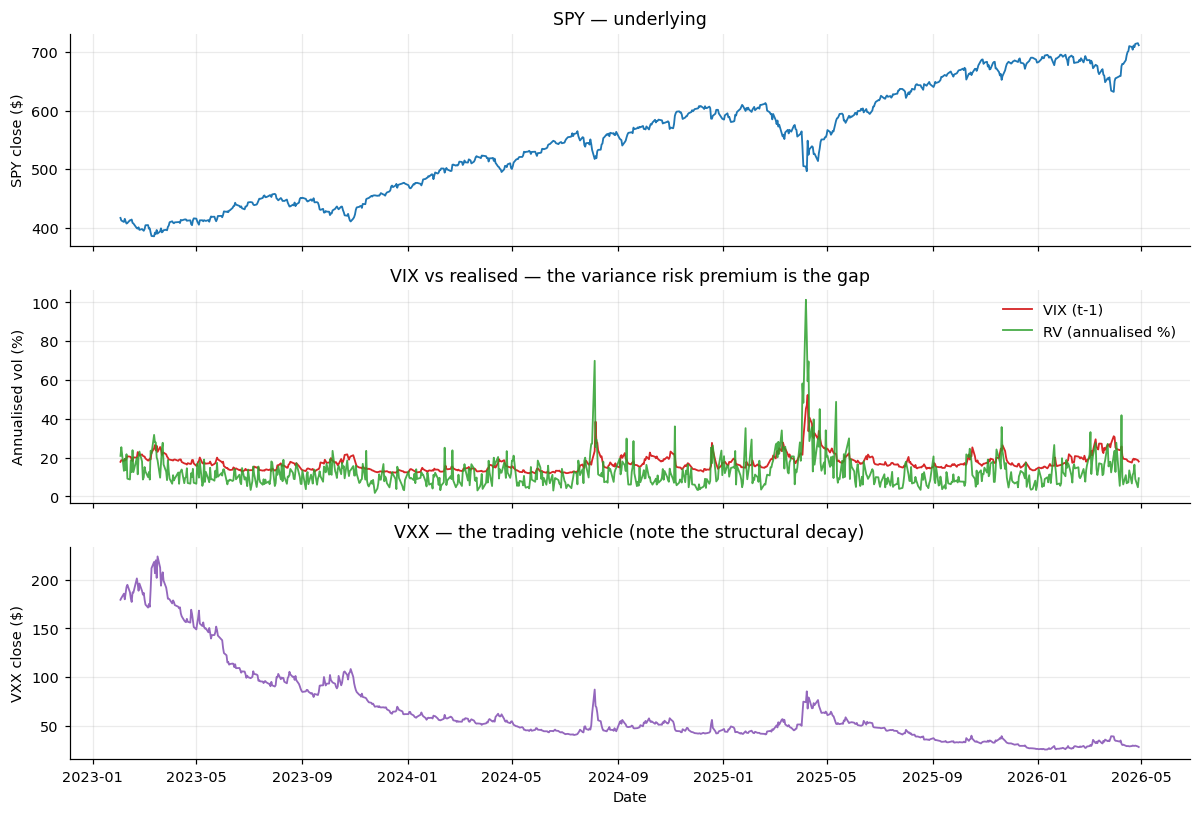

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)

ax = axes[0]
ax.plot(panel.date, panel.spy_close, color='#1f77b4', linewidth=1.2)
ax.set_ylabel('SPY close ($)')
ax.set_title('SPY — underlying')

ax = axes[1]
ax.plot(panel.date, panel.vix_level_lag1, color='#d62728', linewidth=1.2, label='VIX (t-1)')
ax.plot(panel.date, panel.rv * 100, color='#2ca02c', linewidth=1.2, alpha=0.85, label='RV (annualised %)')
ax.set_ylabel('Annualised vol (%)')
ax.set_title('VIX vs realised — the variance risk premium is the gap')
ax.legend(loc='upper right')

ax = axes[2]
ax.plot(panel.date, panel.vxx_close, color='#9467bd', linewidth=1.2)
ax.set_ylabel('VXX close ($)')
ax.set_title('VXX — the trading vehicle (note the structural decay)')
ax.set_xlabel('Date')

fig.tight_layout()
plt.show()

## 2. Target distribution

$y_t = 1$ if tomorrow's RV exceeds its 21-day trailing mean. The base rate is *not* 50% because RV is right-skewed — its **median** is below its **mean**, so on a typical day RV is below the rolling mean and the next day's RV is more likely to also be below.

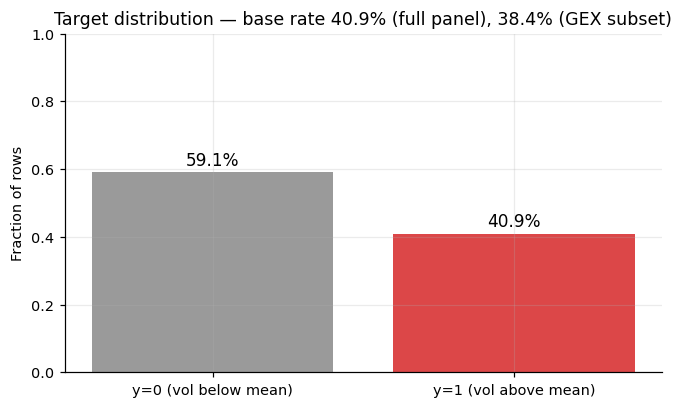

A naive classifier predicting always y=0 achieves accuracy = 59.1%.
Our models therefore have to beat this asymmetric baseline, not just 50%.


In [3]:
base_rate = panel.y_next.mean()
gex_sub = panel.dropna(subset=['gex_net_lag1'])
gex_base_rate = gex_sub.y_next.mean()

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.bar(['y=0 (vol below mean)', 'y=1 (vol above mean)'],
        [(panel.y_next == 0).mean(), base_rate],
        color=['#888888', '#d62728'], alpha=0.85)
ax.set_ylim(0, 1)
ax.set_title(f'Target distribution — base rate {base_rate:.1%} (full panel), {gex_base_rate:.1%} (GEX subset)')
ax.set_ylabel('Fraction of rows')
for i, v in enumerate([(panel.y_next == 0).mean(), base_rate]):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=11)
plt.show()

print(f'A naive classifier predicting always y=0 achieves accuracy = {1-base_rate:.1%}.')
print('Our models therefore have to beat this asymmetric baseline, not just 50%.')

## 3. Volatility clustering — the empirical fact GARCH was invented to model

Engle (1982) noticed that financial volatility is *autocorrelated*: a high-vol day is followed by another high-vol day with much greater than random probability. This is the canonical observation behind ARCH and its descendants (GARCH, FIGARCH, etc.).

Our panel exhibits this directly. Lag-1 autocorrelation of RV is ~0.57, meaning today's RV explains ~32% of the variance of tomorrow's. This is the **primary statistical handle** the strategy uses — and the reason naive "tomorrow looks like today" is a non-trivial baseline.

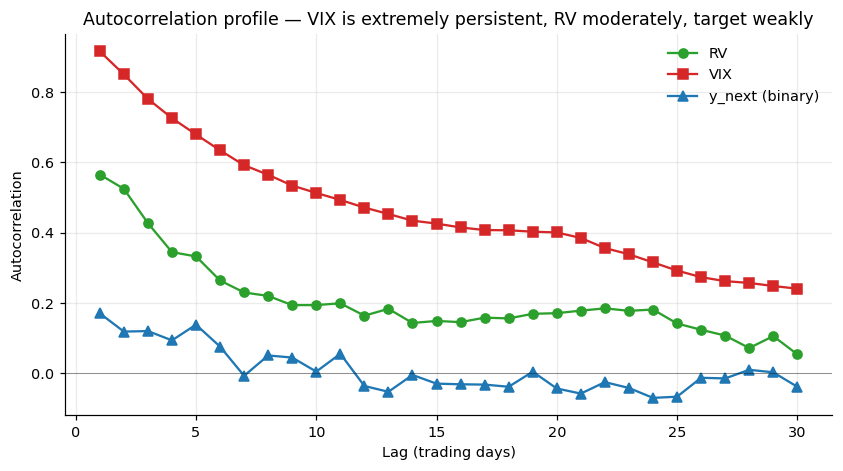

rho_1 (RV)     = 0.565  -- vol clustering
rho_1 (VIX)    = 0.916  -- near unit-root behaviour
rho_1 (target) = 0.170  -- mostly decorrelated by the rolling-mean construction


In [4]:
def autocorr(s, lag):
    s = s.dropna()
    return np.corrcoef(s[:-lag], s[lag:])[0, 1]

lags = range(1, 31)
ac_rv = [autocorr(panel.rv, k) for k in lags]
ac_vix = [autocorr(panel.vix_level_lag1, k) for k in lags]
ac_y = [autocorr(panel.y_next.astype(float), k) for k in lags]

fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
ax.plot(lags, ac_rv, marker='o', label='RV', color='#2ca02c', linewidth=1.5)
ax.plot(lags, ac_vix, marker='s', label='VIX', color='#d62728', linewidth=1.5)
ax.plot(lags, ac_y, marker='^', label='y_next (binary)', color='#1f77b4', linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Lag (trading days)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation profile — VIX is extremely persistent, RV moderately, target weakly')
ax.legend()
plt.show()

print(f'rho_1 (RV)     = {ac_rv[0]:.3f}  -- vol clustering')
print(f'rho_1 (VIX)    = {ac_vix[0]:.3f}  -- near unit-root behaviour')
print(f'rho_1 (target) = {ac_y[0]:.3f}  -- mostly decorrelated by the rolling-mean construction')

## 4. Effective sample size

With autocorrelated data, **each new row is worth less than 1 unit of independent evidence**. The standard AR(1) approximation:

$$N_{\text{eff}} \approx N \cdot \frac{1 - \rho_1}{1 + \rho_1}$$

This is *the* statistical constraint that disciplines everything that follows: model complexity (VC-bound), confidence intervals (bootstrap respect block size), and significance claims (the naive iid p-value is wrong by ~3x).

In [5]:
n_full = len(panel)
n_gex = panel.dropna(subset=['gex_net_lag1']).shape[0]
rho_target = ac_y[0]
rho_vix = ac_vix[0]

def n_eff(n, rho):
    return n * (1 - abs(rho)) / (1 + abs(rho))

rows = []
for n_raw, label in [(n_full, 'full panel'), (n_gex, 'GEX subset')]:
    rows.append({
        'sample': label,
        'N_raw': n_raw,
        'N_eff (target, rho=0.17)': f'{n_eff(n_raw, rho_target):.0f}',
        'N_eff (VIX, rho=0.92)': f'{n_eff(n_raw, rho_vix):.0f}',
    })
df = pd.DataFrame(rows).set_index('sample')
print(df.to_string())

print('\nVC-bound implication:')
print('  - Model parameters must stay << N_eff to avoid overfitting')
print('  - For VIX-driven inference: ~40 effective independent observations')
print('  - For target inference:    ~300-500 effective observations')
print('  - Rules out deep NNs, transformers, LSTMs on this sample')

            N_raw N_eff (target, rho=0.17) N_eff (VIX, rho=0.92)
sample                                                          
full panel    811                      575                    36
GEX subset    435                      308                    19

VC-bound implication:
  - Model parameters must stay << N_eff to avoid overfitting
  - For VIX-driven inference: ~40 effective independent observations
  - For target inference:    ~300-500 effective observations
  - Rules out deep NNs, transformers, LSTMs on this sample


## 5. The VXX vehicle problem

Even if our classifier is *perfect* about regime, we still need to overcome VXX's structural decay. Let's quantify it on our window.

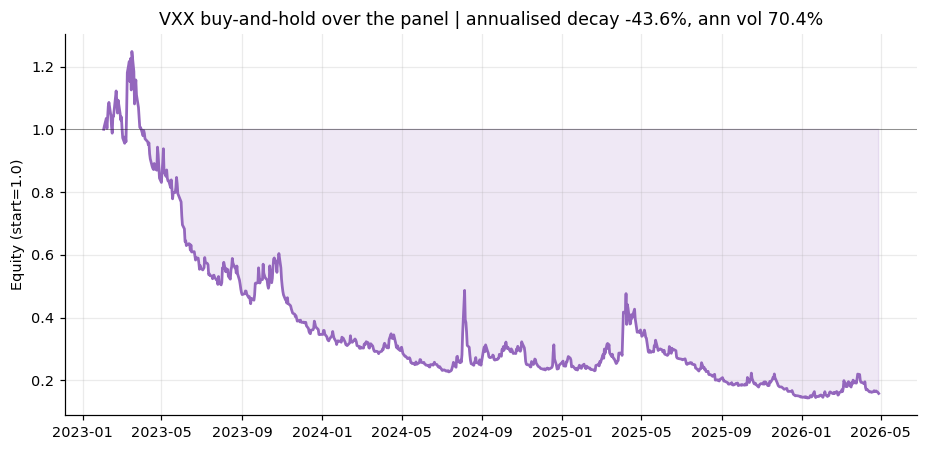

Total VXX return over the panel: -84.2%
Annualised decay              : -43.6%
A long-VXX strategy must overcome roughly 44%/yr just to break even.
This is the structural hurdle every model in this project faces.


In [6]:
vxx = panel.dropna(subset=['vxx_close']).sort_values('date').reset_index(drop=True)
vxx['ret'] = vxx.vxx_close.pct_change()
vxx['equity'] = (1 + vxx.ret.fillna(0)).cumprod()

ann_decay = (vxx.equity.iloc[-1]) ** (252 / len(vxx)) - 1
ann_vol = vxx.ret.std() * np.sqrt(252)

fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))
ax.plot(vxx.date, vxx.equity, color='#9467bd', linewidth=1.8)
ax.axhline(1.0, color='black', linewidth=0.5, alpha=0.5)
ax.set_ylabel('Equity (start=1.0)')
ax.set_title(f'VXX buy-and-hold over the panel | annualised decay {ann_decay*100:.1f}%, ann vol {ann_vol*100:.1f}%')
ax.fill_between(vxx.date, 1.0, vxx.equity, where=(vxx.equity < 1.0), alpha=0.15, color='#9467bd')
plt.show()

print(f'Total VXX return over the panel: {(vxx.equity.iloc[-1] - 1)*100:.1f}%')
print(f'Annualised decay              : {ann_decay*100:.1f}%')
print(f'A long-VXX strategy must overcome roughly {abs(ann_decay)*100:.0f}%/yr just to break even.')
print('This is the structural hurdle every model in this project faces.')

## 6. Where this leads

**The thesis**: VIX-family features (variance risk premium signal) + GEX (dealer-hedging mechanism) should carry information about next-day vol regime. The classifier converts that information into a sized VXX position; the structural hurdle is the contango decay.

**The constraint**: with effective N ~300-500, we can detect AUC differences down to roughly ±0.05 and Sharpe differences down to roughly ±1.0. Anything finer is below the noise floor of this sample.

**What's coming next**:
- `02_signal_construction.ipynb` — how each feature is built, with the math (BS IV inversion for GEX, Yang-Zhang for RV target)
- `03_models_and_results.ipynb` — six model architectures, walk-forward, headline metrics with autocorrelation-adjusted CIs

For the headline numbers and the full honest assessment, see `README.md` and `STATISTICAL_RIGOR.md` at the repo root.